In [1]:
import os
import glob
import numpy as np
import xarray as xr
import dask
import nc_time_axis
from importlib import reload
import xesmf as xe

import matplotlib as mpl
import matplotlib.pyplot as plt
from cartopy import crs as ccrs, feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy

import funcs_grid as gf

In [2]:
import earthaccess

CMR_COLLECTIONS = "https://cmr.earthdata.nasa.gov/search/collections.json"
CMR_GRANULES = "https://cmr.earthdata.nasa.gov/search/granules.json"

chunks = {'time':12}

def preprocessor(ds):
    return ds.rename({'latitude':'lat','longitude':'lon'})

In [3]:
auth = earthaccess.login()
auth

# ECCOv4

In [4]:
short_name = "ECCO_L4_TEMP_SALINITY_05DEG_MONTHLY_V4R4"
temp_ecco4_results = earthaccess.search_data(
    short_name=short_name,
    cloud_hosted=True,
    temporal=("2015-01-01", "2017-01-31"),
)

opened = earthaccess.open(temp_ecco4_results)
# opened = [g.data_links(access="direct")[0] for g in temp_ecco4_results]

temp_ecco4_ds = xr.open_mfdataset(
    opened,
    engine="h5netcdf",
    chunks=chunks,
    concat_dim="time",
    combine="nested",
    data_vars="minimal",
    coords="minimal",
    compat="override", 
    join="exact",
    preprocess=preprocessor,
    parallel=False
)
temp_ecco4_ds

QUEUEING TASKS | :   0%|          | 0/26 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/26 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/26 [00:00<?, ?it/s]

<xarray.Dataset> Size: 3GB
Dimensions:         (time: 26, Z: 50, lat: 360, lon: 720, nv: 2)
Coordinates:
  * time            (time) datetime64[ns] 208B 2014-12-16T12:00:00 ... 2017-0...
  * Z               (Z) float32 200B -5.0 -15.0 -25.0 ... -5.461e+03 -5.906e+03
  * lat             (lat) float32 1kB -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
  * lon             (lon) float32 3kB -179.8 -179.2 -178.8 ... 178.8 179.2 179.8
    time_bnds       (time, nv) datetime64[ns] 416B dask.array<chunksize=(1, 2), meta=np.ndarray>
    latitude_bnds   (lat, nv) float32 3kB dask.array<chunksize=(360, 2), meta=np.ndarray>
    longitude_bnds  (lon, nv) float32 6kB dask.array<chunksize=(720, 2), meta=np.ndarray>
    Z_bnds          (Z, nv) float32 400B dask.array<chunksize=(50, 2), meta=np.ndarray>
Dimensions without coordinates: nv
Data variables:
    THETA           (time, Z, lat, lon) float32 1GB dask.array<chunksize=(1, 25, 180, 360), meta=np.ndarray>
    SALT            (time, Z, lat, lon) float32 1GB dask.array<chunksize=(1, 25, 180, 360), meta=np.ndarray>
Attributes: (12/62)
    acknowledgement:                 This research was carried out by the Jet...
    author:                          Ian Fenty and Ou Wang
    cdm_data_type:                   Grid
    comment:                         Fields provided on a regular lat-lon gri...
    Conventions:                     CF-1.8, ACDD-1.3
    coordinates_comment:             Note: the global 'coordinates' attribute...
    ...                              ...
    time_coverage_duration:          P1M
    time_coverage_end:               2015-01-01T00:00:00
    time_coverage_resolution:        P1M
    time_coverage_start:             2014-12-01T00:00:00
    title:                           ECCO Ocean Temperature and Salinity - Mo...
    uuid:                            853a48ac-4159-11eb-bbe3-0cc47a3f57e1

In [5]:
short_name = "ECCO_L4_SSH_05DEG_MONTHLY_V4R4"
ssh_ecco4_results = earthaccess.search_data(
    short_name=short_name,
    cloud_hosted=True,
    temporal=("2015-01-01", "2017-01-31"),
)

opened = earthaccess.open(ssh_ecco4_results)

ssh_ecco4_ds = xr.open_mfdataset(opened,chunks=chunks,data_vars='minimal',
                                 combine='by_coords',coords='minimal',
                                  preprocess=preprocessor,parallel=True)
ssh_ecco4_ds

QUEUEING TASKS | :   0%|          | 0/86 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/86 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/86 [00:00<?, ?it/s]

/tmp/ipykernel_142/2029228179.py:10: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ssh_ecco4_ds = xr.open_mfdataset(opened,chunks=chunks,data_vars='minimal',
/tmp/ipykernel_142/2029228179.py:10: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ssh_ecco4_ds = xr.open_mfdataset(opened,chunks=chunks,data_vars='minimal',


<xarray.Dataset> Size: 268MB
Dimensions:         (time: 86, lat: 360, lon: 720, nv: 2)
Coordinates:
  * time            (time) datetime64[ns] 688B 2009-12-16T12:00:00 ... 2017-0...
  * lat             (lat) float32 1kB -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
  * lon             (lon) float32 3kB -179.8 -179.2 -178.8 ... 178.8 179.2 179.8
    time_bnds       (time, nv) datetime64[ns] 1kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    latitude_bnds   (lat, nv) float32 3kB dask.array<chunksize=(360, 2), meta=np.ndarray>
    longitude_bnds  (lon, nv) float32 6kB dask.array<chunksize=(720, 2), meta=np.ndarray>
Dimensions without coordinates: nv
Data variables:
    SSH             (time, lat, lon) float32 89MB dask.array<chunksize=(1, 360, 720), meta=np.ndarray>
    SSHIBC          (time, lat, lon) float32 89MB dask.array<chunksize=(1, 360, 720), meta=np.ndarray>
    SSHNOIBC        (time, lat, lon) float32 89MB dask.array<chunksize=(1, 360, 720), meta=np.ndarray>
Attributes: (12/57)
    acknowledgement:              This research was carried out by the Jet Pr...
    author:                       Ian Fenty and Ou Wang
    cdm_data_type:                Grid
    comment:                      Fields provided on a regular lat-lon grid. ...
    Conventions:                  CF-1.8, ACDD-1.3
    coordinates_comment:          Note: the global 'coordinates' attribute de...
    ...                           ...
    time_coverage_duration:       P1M
    time_coverage_end:            2010-01-01T00:00:00
    time_coverage_resolution:     P1M
    time_coverage_start:          2009-12-01T00:00:00
    title:                        ECCO Sea Surface Height - Monthly Mean 0.5 ...
    uuid:                         09063238-4158-11eb-bd4a-0cc47a3f7e53

In [6]:
reload(gf)
dx_ecco4_5deg,dy_ecco4_5deg = gf.cdtdim_xr(ssh_ecco4_ds.lat,ssh_ecco4_ds.lon)
coriolis = gf.calc_coriolis(ssh_ecco4_ds.lat)
g = 9.81

vgos_ecco4_5deg = (g/coriolis)*gf.xr_first_derivative(ssh_ecco4_ds.SSH,dx_ecco4_5deg,dim='lon')
vgos_ecco4_5deg = vgos_ecco4_5deg.where(abs(vgos_ecco4_5deg.lat) > 2)

In [7]:
sst_ecco4_5deg = temp_ecco4_ds.THETA.isel(Z=0,drop=True)
sst_ecco4_5deg

<xarray.DataArray 'THETA' (time: 26, lat: 360, lon: 720)> Size: 27MB
dask.array<getitem, shape=(26, 360, 720), dtype=float32, chunksize=(1, 180, 360), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 208B 2014-12-16T12:00:00 ... 2017-01-16T12...
  * lat      (lat) float32 1kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * lon      (lon) float32 3kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
Attributes:
    coverage_content_type:  modelResult
    long_name:              Potential temperature 
    standard_name:          sea_water_potential_temperature
    units:                  degree_C
    comment:                Sea water potential temperature is the temperatur...
    valid_min:              -2.2909388542175293
    valid_max:              36.032955169677734

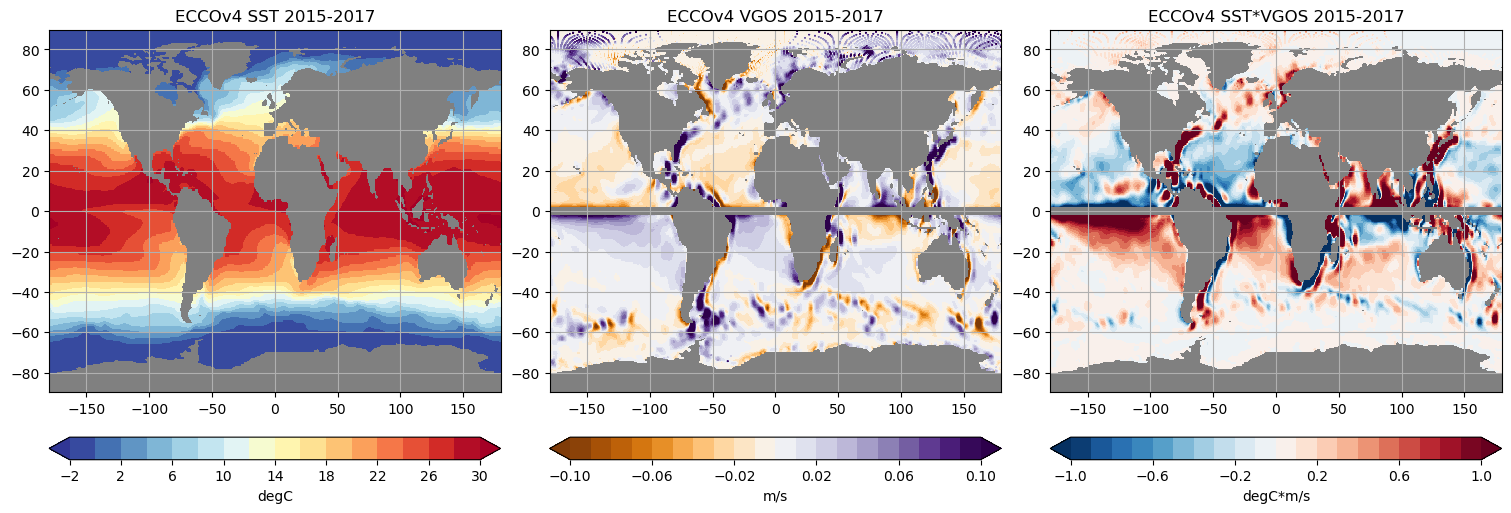

In [8]:
fig,axs = plt.subplots(1,3,figsize=(15,5),layout='constrained')

ax = axs[0] ; ax.set_title('ECCOv4 SST 2015-2017')
dat = sst_ecco4_5deg.mean('time')
cmap = 'RdYlBu_r' ; levels = np.arange(-2,31,2)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::2],orientation='horizontal',label='degC')

ax = axs[1] ; ax.set_title('ECCOv4 VGOS 2015-2017')
dat = vgos_ecco4_5deg.mean('time')
cmap = 'PuOr' ; levels = np.linspace(-0.1,0.1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='m/s')

ax = axs[2] ; ax.set_title('ECCOv4 SST*VGOS 2015-2017')
dat = (sst_ecco4_5deg*vgos_ecco4_5deg).mean('time')
cmap = 'RdBu_r' ; levels = np.linspace(-1,1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='degC*m/s')

for ax in axs:
    ax.grid()
    ax.set_facecolor('gray')
    

# Observations

In [9]:
auth = earthaccess.login()

In [11]:
chunks = {'time':10,'latitude':100,'longitude':100}

def preprocessor(ds):
    ds0 = ds.resample(time='1MS').mean()
    return ds0
    
short_name = "MUR25-JPL-L4-GLOB-v04.2"

sst_mur25_results = earthaccess.search_data(
    short_name=short_name,
    cloud_hosted=True,
    temporal=("2015-01-01", "2017-12-31"),
)

opened = earthaccess.open(sst_mur25_results)

sst_mur25_ds = xr.open_mfdataset(opened,chunks=chunks,data_vars='minimal',
                                 combine='by_coords',coords='minimal',
                                 preprocess=preprocessor,parallel=False) - 273.15


QUEUEING TASKS | :   0%|          | 0/1097 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1097 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1097 [00:00<?, ?it/s]

In [ ]:
chunks = {'time':10,'latitude':100,'longitude':100}
def preprocessor(ds):
    ds0 = ds0.resample(time='1MS').mean().astype(np.float32)
    return ds0

short_name = "NEUROST_SSH-SST_L4_V2024.0"

ssh_neuro_results = earthaccess.search_data(
    short_name=short_name,
    cloud_hosted=True,
    temporal=("2015-01-01", "2017-12-31"),
)

opened = earthaccess.open(ssh_neuro_results)
ssh_neuro_ds = xr.open_mfdataset(opened,chunks=chunks,data_vars='minimal',
                                 combine='by_coords',coords='minimal',
                                 preprocess=preprocessor,parallel=False)
ssh_neuro_ds

QUEUEING TASKS | :   0%|          | 0/1097 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1097 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1097 [00:00<?, ?it/s]

In [26]:
# sst_mur25 remap
outdir = '~/tamu/ocng-689/ocng-489-689-2026-spring/tprochko/grids/'
fout = 'sst_mur25_to_ecco4_5deg_bilinear_remap.nc'
ds_in = sst_mur25_ds.analysed_sst.isel(time=0,drop=True).rename({'lat':'y','lon':'x'})
ds_out = xr.Dataset(
    {
        "lat": (["lat"], ssh_ecco4_ds.lat.data, {"units": "degrees_north"}),
        "lon": (["lon"], ssh_ecco4_ds.lon.data, {"units": "degrees_east"}),
    }
)

In [27]:
%%time
regridder = xe.Regridder(ds_in, ds_out, 'bilinear')
# tried periodic=True, but it kept blowing up. 
fn = regridder.to_netcdf(os.path.join(outdir,fout))
regridder

CPU times: user 16.6 s, sys: 375 ms, total: 17 s
Wall time: 17.2 s


xESMF Regridder 
Regridding algorithm:       bilinear 
Weight filename:            bilinear_720x1440_360x720.nc 
Reuse pre-computed weights? False 
Input grid shape:           (720, 1440) 
Output grid shape:          (360, 720) 
Periodic in longitude?      False

In [13]:
# ssh_neuro remap
outdir = '~/tamu/ocng-689/ocng-489-689-2026-spring/tprochko/grids/'
fout = 'ssh_neuro_to_ecco4_5deg_bilinear_remap.nc'
ds_in = ssh_neuro_ds.vgos.isel(time=0,drop=True).rename({'lat':'y','lon':'x'})
ds_out = xr.Dataset(
    {
        "lat": (["lat"], ssh_ecco4_ds.lat.data, {"units": "degrees_north"}),
        "lon": (["lon"], ssh_ecco4_ds.lon.data, {"units": "degrees_east"}),
    }
)

<xarray.DataArray 'vgos' (y: 1500, x: 3600)> Size: 22MB
dask.array<getitem, shape=(1500, 3600), dtype=float32, chunksize=(1500, 3600), chunktype=numpy.ndarray>
Coordinates:
  * y                       (y) float64 12kB -70.0 -69.9 -69.8 ... 79.8 79.9
  * x                       (x) float64 29kB 0.1 0.2 0.3 ... 359.8 359.9 360.0
    Lambert_Azimuthal_Grid  int32 4B -2147483647
Attributes:
    long_name:              northward surface geostrophic current velocity
    standard_name:          surface_geostrophic_northward_sea_water_velocity
    units:                  m/s
    coverage_content_type:  modelResult
    valid_range:            [-1.e+09  1.e+09]
    grid_mapping:           crs

In [19]:
%%time
regridder = xe.Regridder(ds_in, ds_out, 'bilinear')
# tried periodic=True, but it kept blowing up. 
fn = regridder.to_netcdf(os.path.join(outdir,fout))
regridder

CPU times: user 1min 12s, sys: 2.39 s, total: 1min 14s
Wall time: 1min 14s


xESMF Regridder 
Regridding algorithm:       bilinear 
Weight filename:            bilinear_1500x3600_360x720.nc 
Reuse pre-computed weights? False 
Input grid shape:           (1500, 3600) 
Output grid shape:          (360, 720) 
Periodic in longitude?      False

In [ ]:
ds_in = sst_mur25_ds.analysed_sst.isel(time=0,drop=True).rename({'lat':'y','lon':'x'})
ds_out = xr.Dataset(
    {
        "lat": (["lat"], ssh_ecco4_ds.lat.data, {"units": "degrees_north"}),
        "lon": (["lon"], ssh_ecco4_ds.lon.data, {"units": "degrees_east"}),
    }
)
fdir = '/home/jovyan/tamu/ocng-689/ocng-489-689-2026-spring/tprochko/grids/'
fname = 'sst_mur25_to_ecco4_5deg_bilinear_remap.nc'
fin = os.path.join(fdir,fname)
sst_mur25_regridder = xe.Regridder(ds_in, ds_out, 'bilinear', weights=fin)

ds_in = ssh_neuro_ds.adt.isel(time=0,drop=True).rename({'lat':'y','lon':'x'})
fdir = '/home/jovyan/tamu/ocng-689/ocng-489-689-2026-spring/tprochko/grids/'
fname = 'ssh_neuro_to_ecco4_5deg_bilinear_remap.nc'
fin = os.path.join(fdir,fname)
ssh_neuro_regridder = xe.Regridder(ds_in, ds_out, 'bilinear', weights=fin)

In [ ]:
%%time
sst_mur25_5deg = sst_mur25_regridder(sst_mur25_ds.analysed_sst.rename({'lat':'y','lon':'x'}))
ssh_neuro_5deg = ssh_neuro_regridder(ssh_neuro_ds.adt.rename({'lat':'y','lon':'x'}))

sst_mur25_5deg = sst_mur25_5deg.compute()#.rename({'y':'lat','x':'lon'}))
ssh_neuro_5deg = ssh_neuro_5deg.compute()#.rename({'y':'lat','x':'lon'}))

In [ ]:
reload(gf)

vgos_neuro_5deg = (g/coriolis)*gf.xr_first_derivative(ssh_neuro_5deg,dx_ecco4_5deg,dim='lon')
vgos_neuro_5deg = vgos_neuro_5deg.where(abs(vgos_neuro_5deg.lat) > 2)

In [ ]:
fig,axs = plt.subplots(1,3,figsize=(15,5),layout='constrained')

ax = axs[0] ; ax.set_title('MUR25 SST 2015-2017')
dat = sst_mur25_5deg.mean('time')
cmap = 'RdYlBu_r' ; levels = np.arange(-2,31,2)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::2],orientation='horizontal',label='degC')

ax = axs[1] ; ax.set_title('NeurOST VGOS 2015-2017')
dat = vgos_neuro_5deg.mean('time')
cmap = 'PuOr' ; levels = np.linspace(-0.1,0.1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='m/s')

ax = axs[2] ; ax.set_title('MUR25+NeurOST SST*VGOS 2015-2017')
dat = (sst_mur25_5deg*vgos_neuro_5deg).mean('time')
cmap = 'RdBu_r' ; levels = np.linspace(-1,1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='degC*m/s')

for ax in axs:
    ax.grid()
    ax.set_facecolor('gray')
    

/srv/conda/envs/notebook/lib/python3.12/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)


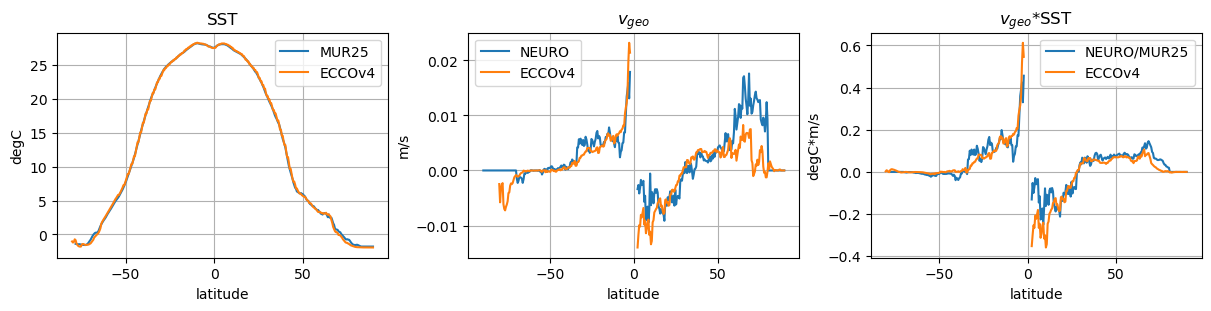

In [98]:
fig,axs = plt.subplots(1,3,figsize=(12,3),layout='constrained')

ax = axs[0] ; ax.set_title('SST')
dat = sst_mur25_5deg.mean('time').mean('lon')
ax.plot(dat.lat,dat,color='C0',label='MUR25')
dat = sst_ecco4_ds.mean('time').mean('lon')
ax.plot(dat.lat,dat,color='C1',label='ECCOv4')
ax.set_ylabel('degC')

ax = axs[1] ; ax.set_title('$v_{geo}$')
dat = vgos_neuro_5deg.mean('time').mean('lon')
ax.plot(dat.lat,dat,color='C0',label='NEURO')
dat = vgos_ecco4_5deg.mean('time').mean('lon')
ax.plot(dat.lat,dat,color='C1',label='ECCOv4')
ax.set_ylabel('m/s')

ax = axs[2] ; ax.set_title('$v_{geo}$*SST')
dat = (sst_mur25_5deg*vgos_neuro_5deg).mean('time').mean('lon')
ax.plot(dat.lat,dat,color='C0',label='NEURO/MUR25')
dat = (sst_ecco4_ds*vgos_ecco5_5deg).mean('time').mean('lon')
ax.plot(dat.lat,dat,color='C1',label='ECCOv4')
ax.set_ylabel('degC*m/s')

for ax in axs:
    ax.grid()
    ax.legend()
    ax.set_xlabel('latitude')

In [72]:
# NeuroSSH dataset too noisy, lets try smoothing it before remapping.

In [82]:
import numpy as np
from scipy.ndimage import gaussian_filter

def xr_gaussian_smooth(da, sigma=10):
    """
    Smoothes an xarray.DataArray with NaN handling and coordinate preservation.
    """
    def _smooth_func(arr, sigma_val):
        # Separate data and mask
        mask = np.isfinite(arr).astype(np.float32)
        filled = np.nan_to_num(arr, nan=0.0)
        
        # Smooth both (mode='wrap' for longitude)
        s_data = gaussian_filter(filled, sigma=sigma_val, mode='wrap')
        s_mask = gaussian_filter(mask, sigma=sigma_val, mode='wrap')
        
        # Normalize and re-mask
        return np.where(mask > 0, s_data / np.maximum(s_mask, 1e-10), np.nan)

    # Apply via ufunc to keep xarray metadata
    smoothed = xr.apply_ufunc(
        _smooth_func,
        da,
        kwargs={'sigma_val': sigma},
        dask='parallelized',
        output_dtypes=[da.dtype]
    )
    
    return smoothed

In [83]:
ssh_neuro_smooth = xr_gaussian_smooth(ssh_neuro_ds.adt)
ssh_neuro_smooth_5deg = ssh_neuro_regridder(ssh_neuro_smooth.rename({'lat':'y','lon':'x'}))

In [84]:
ssh_neuro_smooth_5deg = ssh_neuro_smooth_5deg.compute()

In [85]:
vgos_neuro_smooth_5deg = (g/coriolis)*gf.xr_first_derivative(ssh_neuro_smooth_5deg,dx_ecco4_5deg,dim='lon')
vgos_neuro_smooth_5deg = vgos_neuro_smooth_5deg.where(abs(vgos_neuro_smooth_5deg.lat) > 2)

/srv/conda/envs/notebook/lib/python3.12/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)


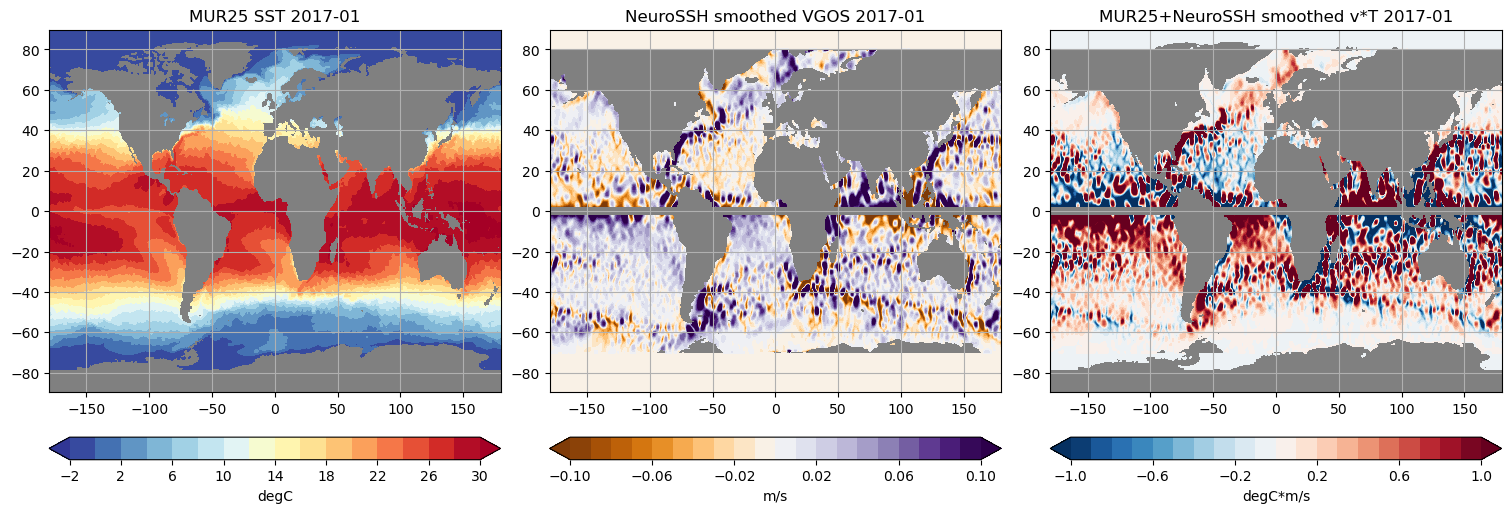

In [87]:
fig,axs = plt.subplots(1,3,figsize=(15,5),layout='constrained')

ax = axs[0] ; ax.set_title('MUR25 SST 2017-01')
dat = sst_mur25_5deg.mean('time')
cmap = 'RdYlBu_r' ; levels = np.arange(-2,31,2)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::2],orientation='horizontal',label='degC')

ax = axs[1] ; ax.set_title('NeuroSSH smoothed VGOS 2017-01')
dat = vgos_neuro_smooth_5deg.mean('time')
cmap = 'PuOr' ; levels = np.linspace(-0.1,0.1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='m/s')

ax = axs[2] ; ax.set_title('MUR25+NeuroSSH smoothed v*T 2017-01')
dat = (sst_mur25_5deg*vgos_neuro_smooth_5deg).mean('time')
cmap = 'RdBu_r' ; levels = np.linspace(-1,1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='degC*m/s')

for ax in axs:
    ax.grid()
    ax.set_facecolor('gray')
    

/srv/conda/envs/notebook/lib/python3.12/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)


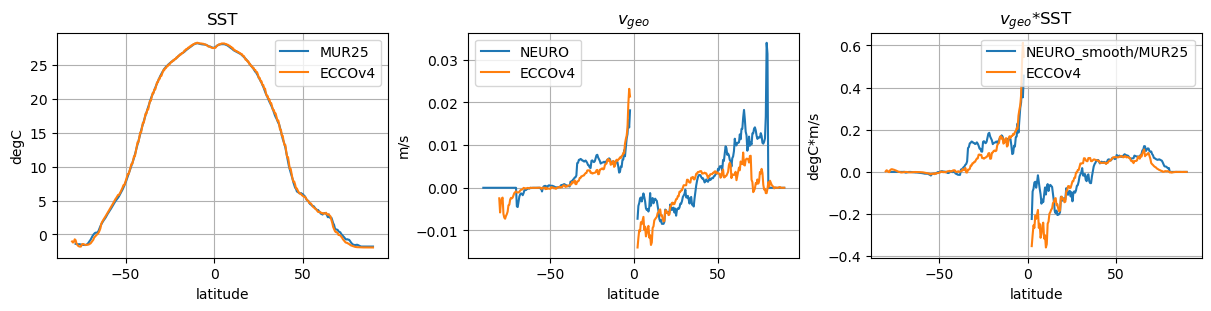

In [99]:
fig,axs = plt.subplots(1,3,figsize=(12,3),layout='constrained')

ax = axs[0] ; ax.set_title('SST')
dat = sst_mur25_5deg.mean('time').mean('lon')
ax.plot(dat.lat,dat,color='C0',label='MUR25')
dat = sst_ecco4_ds.mean('time').mean('lon')
ax.plot(dat.lat,dat,color='C1',label='ECCOv4')
ax.set_ylabel('degC')

ax = axs[1] ; ax.set_title('$v_{geo}$')
dat = vgos_neuro_smooth_5deg.mean('time').mean('lon')
ax.plot(dat.lat,dat,color='C0',label='NEURO')
dat = vgos_ecco4_5deg.mean('time').mean('lon')
ax.plot(dat.lat,dat,color='C1',label='ECCOv4')
ax.set_ylabel('m/s')

ax = axs[2] ; ax.set_title('$v_{geo}$*SST')
dat = (sst_mur25_5deg*vgos_neuro_smooth_5deg).mean('time').mean('lon')
ax.plot(dat.lat,dat,color='C0',label='NEURO_smooth/MUR25')
dat = (sst_ecco4_ds*vgos_ecco5_5deg).mean('time').mean('lon')
ax.plot(dat.lat,dat,color='C1',label='ECCOv4')
ax.set_ylabel('degC*m/s')

for ax in axs:
    ax.grid()
    ax.legend()
    ax.set_xlabel('latitude')

# Comparison

/srv/conda/envs/notebook/lib/python3.12/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)
/srv/conda/envs/notebook/lib/python3.12/site-packages/numbagg/decorators.py:245: RuntimeWarning: invalid value encountered in nanmean
  return self.gufunc(target=self.target)(*arrays, axis=-1)


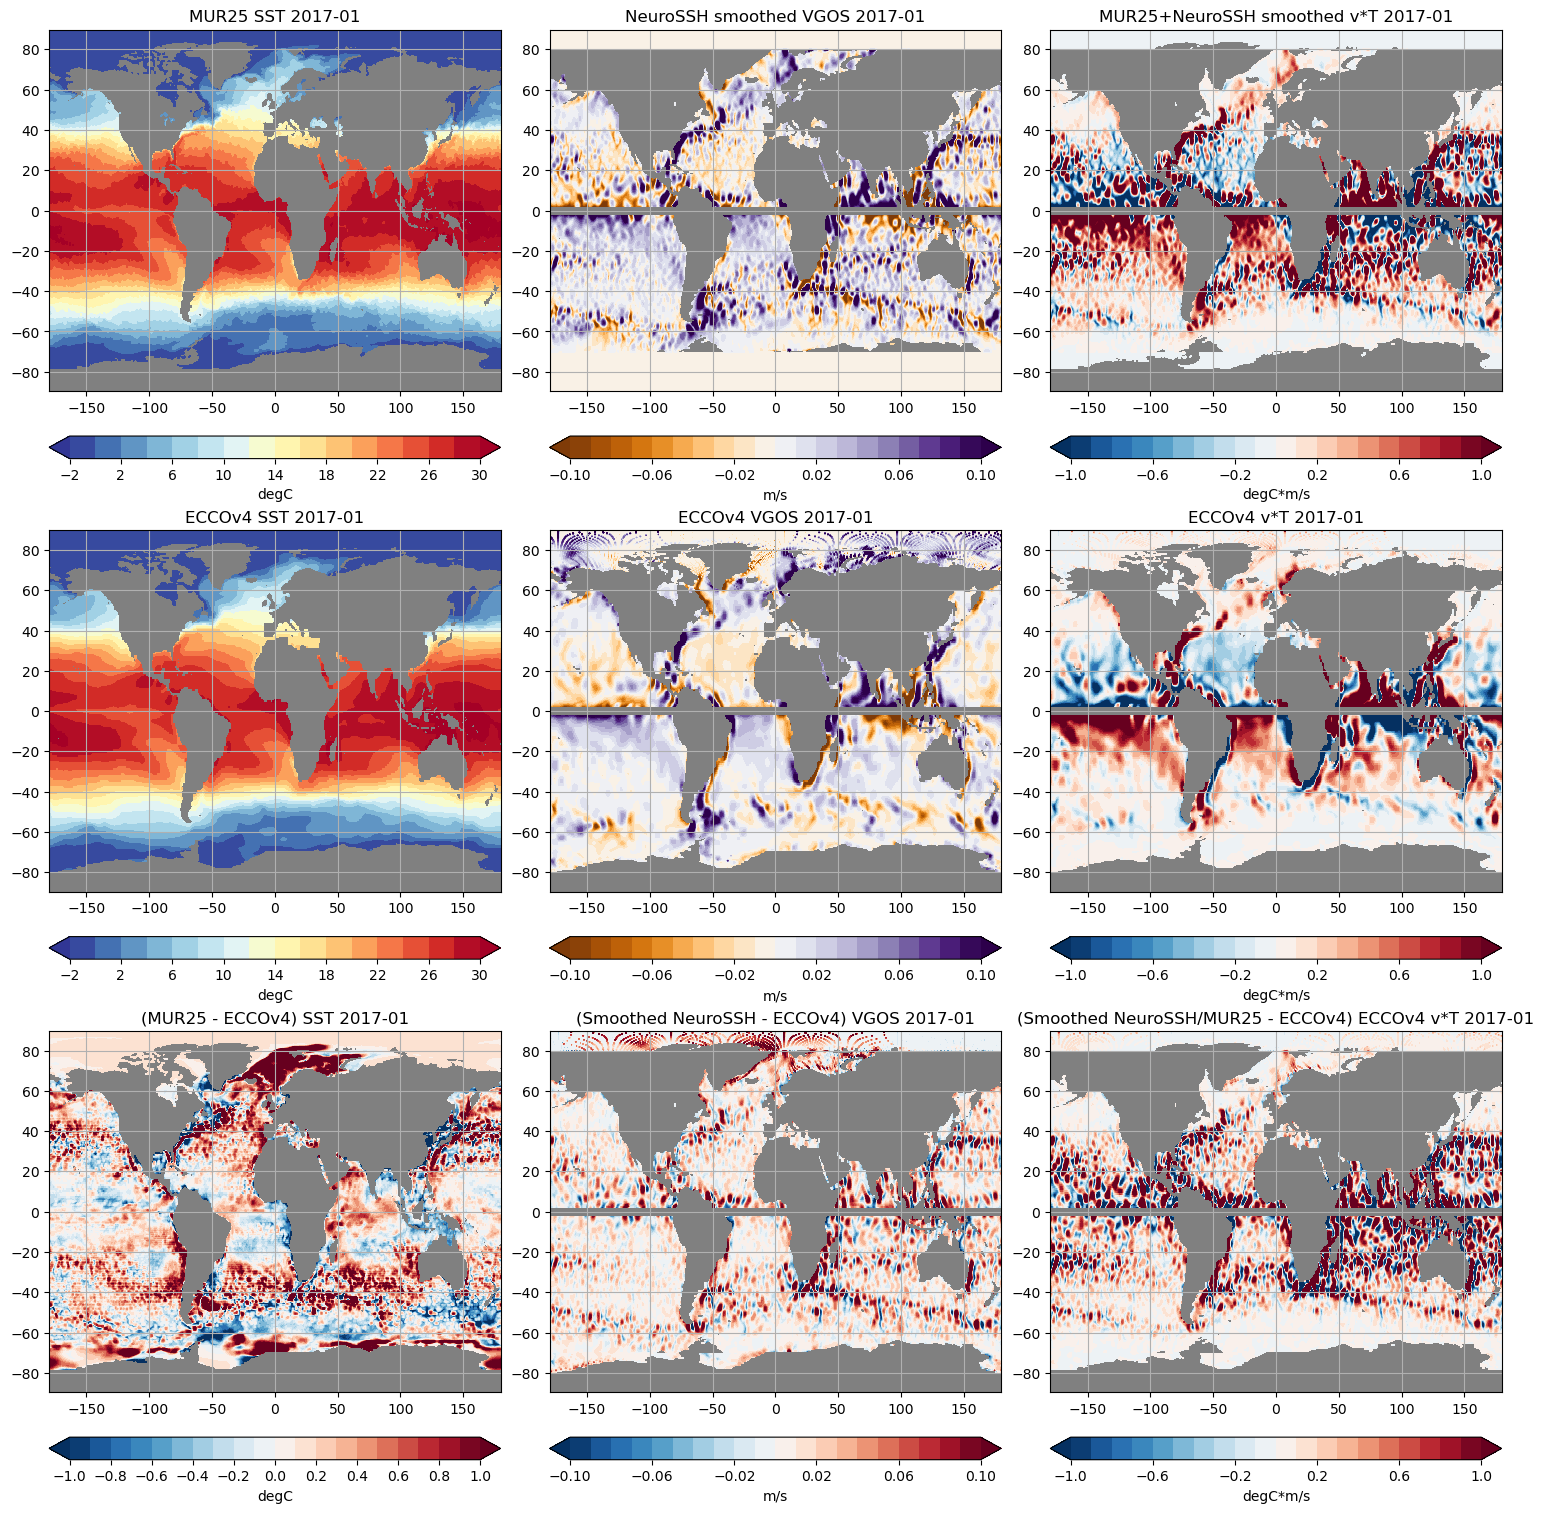

In [90]:
fig,axs = plt.subplots(3,3,figsize=(15,15),layout='constrained')

ax = axs[0,0] ; ax.set_title('MUR25 SST 2017-01')
dat = sst_mur25_5deg.mean('time')
cmap = 'RdYlBu_r' ; levels = np.arange(-2,31,2)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::2],orientation='horizontal',label='degC')

ax = axs[0,1] ; ax.set_title('NeuroSSH smoothed VGOS 2017-01')
dat = vgos_neuro_smooth_5deg.mean('time')
cmap = 'PuOr' ; levels = np.linspace(-0.1,0.1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='m/s')

ax = axs[0,2] ; ax.set_title('MUR25+NeuroSSH smoothed v*T 2017-01')
dat = (sst_mur25_5deg*vgos_neuro_smooth_5deg).mean('time')
cmap = 'RdBu_r' ; levels = np.linspace(-1,1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='degC*m/s')

ax = axs[1,0] ; ax.set_title('ECCOv4 SST 2017-01')
dat = sst_ecco4_ds.mean('time')
cmap = 'RdYlBu_r' ; levels = np.arange(-2,31,2)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::2],orientation='horizontal',label='degC')

ax = axs[1,1] ; ax.set_title('ECCOv4 VGOS 2017-01')
dat = vgos_ecco5_5deg.mean('time')
cmap = 'PuOr' ; levels = np.linspace(-0.1,0.1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='m/s')

ax = axs[1,2] ; ax.set_title('ECCOv4 v*T 2017-01')
dat = (sst_ecco4_ds*vgos_ecco5_5deg).mean('time')
cmap = 'RdBu_r' ; levels = np.linspace(-1,1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='degC*m/s')

ax = axs[2,0] ; ax.set_title('(MUR25 - ECCOv4) SST 2017-01')
dat = sst_mur25_5deg.mean('time') - sst_ecco4_ds.mean('time')
cmap = 'RdBu_r' ; levels = np.linspace(-1,1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::2],orientation='horizontal',label='degC')

ax = axs[2,1] ; ax.set_title('(Smoothed NeuroSSH - ECCOv4) VGOS 2017-01')
dat = vgos_neuro_smooth_5deg.mean('time') - vgos_ecco5_5deg.mean('time')
cmap = 'RdBu_r' ; levels = np.linspace(-0.1,0.1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='m/s')

ax = axs[2,2] ; ax.set_title('(Smoothed NeuroSSH/MUR25 - ECCOv4) ECCOv4 v*T 2017-01')
dat = (sst_mur25_5deg*vgos_neuro_smooth_5deg).mean('time') - (sst_ecco4_ds*vgos_ecco5_5deg).mean('time')
cmap = 'RdBu_r' ; levels = np.linspace(-1,1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='degC*m/s')

for ax in axs.flat:
    ax.grid()
    ax.set_facecolor('gray')
    

# Deeper levels

In [4]:
short_name = "ECCO_L4_TEMP_SALINITY_05DEG_DAILY_V4R4"
temp_ecco4_results = earthaccess.search_data(
    short_name=short_name,
    cloud_hosted=True,
    temporal=("2017-01-01", "2017-01-31"),
)

opened = earthaccess.open(temp_ecco4_results)

temp_ecco4_ds = xr.open_mfdataset(opened,chunks=chunks,data_vars='minimal',
                                 combine='by_coords',coords='minimal',
                                  preprocess=preprocessor,parallel=True)
temp_ecco4_ds

QUEUEING TASKS | :   0%|          | 0/32 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/32 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/32 [00:00<?, ?it/s]

/tmp/ipykernel_109/426970175.py:10: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  temp_ecco4_ds = xr.open_mfdataset(opened,chunks=chunks,data_vars='minimal',
/tmp/ipykernel_109/426970175.py:10: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  temp_ecco4_ds = xr.open_mfdataset(opened,chunks=chunks,data_vars='minimal',
/tmp/ipykernel_109/4

<xarray.Dataset> Size: 3GB
Dimensions:         (time: 32, Z: 50, lat: 360, lon: 720, nv: 2)
Coordinates:
  * time            (time) datetime64[ns] 256B 2016-12-31T12:00:00 ... 2017-0...
  * Z               (Z) float32 200B -5.0 -15.0 -25.0 ... -5.461e+03 -5.906e+03
  * lat             (lat) float32 1kB -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
  * lon             (lon) float32 3kB -179.8 -179.2 -178.8 ... 178.8 179.2 179.8
    time_bnds       (time, nv) datetime64[ns] 512B dask.array<chunksize=(1, 2), meta=np.ndarray>
    latitude_bnds   (lat, nv) float32 3kB dask.array<chunksize=(360, 2), meta=np.ndarray>
    longitude_bnds  (lon, nv) float32 6kB dask.array<chunksize=(720, 2), meta=np.ndarray>
    Z_bnds          (Z, nv) float32 400B dask.array<chunksize=(50, 2), meta=np.ndarray>
Dimensions without coordinates: nv
Data variables:
    THETA           (time, Z, lat, lon) float32 2GB dask.array<chunksize=(1, 25, 180, 360), meta=np.ndarray>
    SALT            (time, Z, lat, lon) float32 2GB dask.array<chunksize=(1, 25, 180, 360), meta=np.ndarray>
Attributes: (12/62)
    acknowledgement:                 This research was carried out by the Jet...
    author:                          Ian Fenty and Ou Wang
    cdm_data_type:                   Grid
    comment:                         Fields provided on a regular lat-lon gri...
    Conventions:                     CF-1.8, ACDD-1.3
    coordinates_comment:             Note: the global 'coordinates' attribute...
    ...                              ...
    time_coverage_duration:          P1D
    time_coverage_end:               2017-01-01T00:00:00
    time_coverage_resolution:        P1D
    time_coverage_start:             2016-12-31T00:00:00
    title:                           ECCO Ocean Temperature and Salinity - Da...
    uuid:                            1581c426-4128-11eb-8800-0cc47a3f575f

In [5]:
short_name = "ECCO_L4_OCEAN_VEL_05DEG_DAILY_V4R4"
vel_ecco4_results = earthaccess.search_data(
    short_name=short_name,
    cloud_hosted=True,
    temporal=("2017-01-01", "2017-01-31"),
)

opened = earthaccess.open(vel_ecco4_results)

vel_ecco4_ds = xr.open_mfdataset(opened,chunks=chunks,data_vars='minimal',
                                 combine='by_coords',coords='minimal',
                                  preprocess=preprocessor,parallel=True)
vel_ecco4_ds

QUEUEING TASKS | :   0%|          | 0/32 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/32 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/32 [00:00<?, ?it/s]

/tmp/ipykernel_109/2078940821.py:10: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  vel_ecco4_ds = xr.open_mfdataset(opened,chunks=chunks,data_vars='minimal',
/tmp/ipykernel_109/2078940821.py:10: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  vel_ecco4_ds = xr.open_mfdataset(opened,chunks=chunks,data_vars='minimal',
/tmp/ipykernel_109/2

<xarray.Dataset> Size: 5GB
Dimensions:         (time: 32, Z: 50, lat: 360, lon: 720, nv: 2)
Coordinates:
  * time            (time) datetime64[ns] 256B 2016-12-31T12:00:00 ... 2017-0...
  * Z               (Z) float32 200B -5.0 -15.0 -25.0 ... -5.461e+03 -5.906e+03
  * lat             (lat) float32 1kB -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
  * lon             (lon) float32 3kB -179.8 -179.2 -178.8 ... 178.8 179.2 179.8
    time_bnds       (time, nv) datetime64[ns] 512B dask.array<chunksize=(1, 2), meta=np.ndarray>
    latitude_bnds   (lat, nv) float32 3kB dask.array<chunksize=(360, 2), meta=np.ndarray>
    longitude_bnds  (lon, nv) float32 6kB dask.array<chunksize=(720, 2), meta=np.ndarray>
    Z_bnds          (Z, nv) float32 400B dask.array<chunksize=(50, 2), meta=np.ndarray>
Dimensions without coordinates: nv
Data variables:
    EVEL            (time, Z, lat, lon) float32 2GB dask.array<chunksize=(1, 25, 180, 360), meta=np.ndarray>
    NVEL            (time, Z, lat, lon) float32 2GB dask.array<chunksize=(1, 25, 180, 360), meta=np.ndarray>
    WVEL            (time, Z, lat, lon) float32 2GB dask.array<chunksize=(1, 25, 180, 360), meta=np.ndarray>
Attributes: (12/62)
    acknowledgement:                 This research was carried out by the Jet...
    author:                          Ian Fenty and Ou Wang
    cdm_data_type:                   Grid
    comment:                         Fields provided on a regular lat-lon gri...
    Conventions:                     CF-1.8, ACDD-1.3
    coordinates_comment:             Note: the global 'coordinates' attribute...
    ...                              ...
    time_coverage_duration:          P1D
    time_coverage_end:               2017-01-01T00:00:00
    time_coverage_resolution:        P1D
    time_coverage_start:             2016-12-31T00:00:00
    title:                           ECCO Ocean Velocity - Daily Mean 0.5 Deg...
    uuid:                            f47bcd60-413d-11eb-9afd-0cc47a3f5785

In [6]:
temp_ecco4_5deg = temp_ecco4_ds.THETA
vvel_ecco4_5deg = vel_ecco4_ds.NVEL

In [7]:
vt_ecco4_5deg = temp_ecco4_5deg*vvel_ecco4_5deg

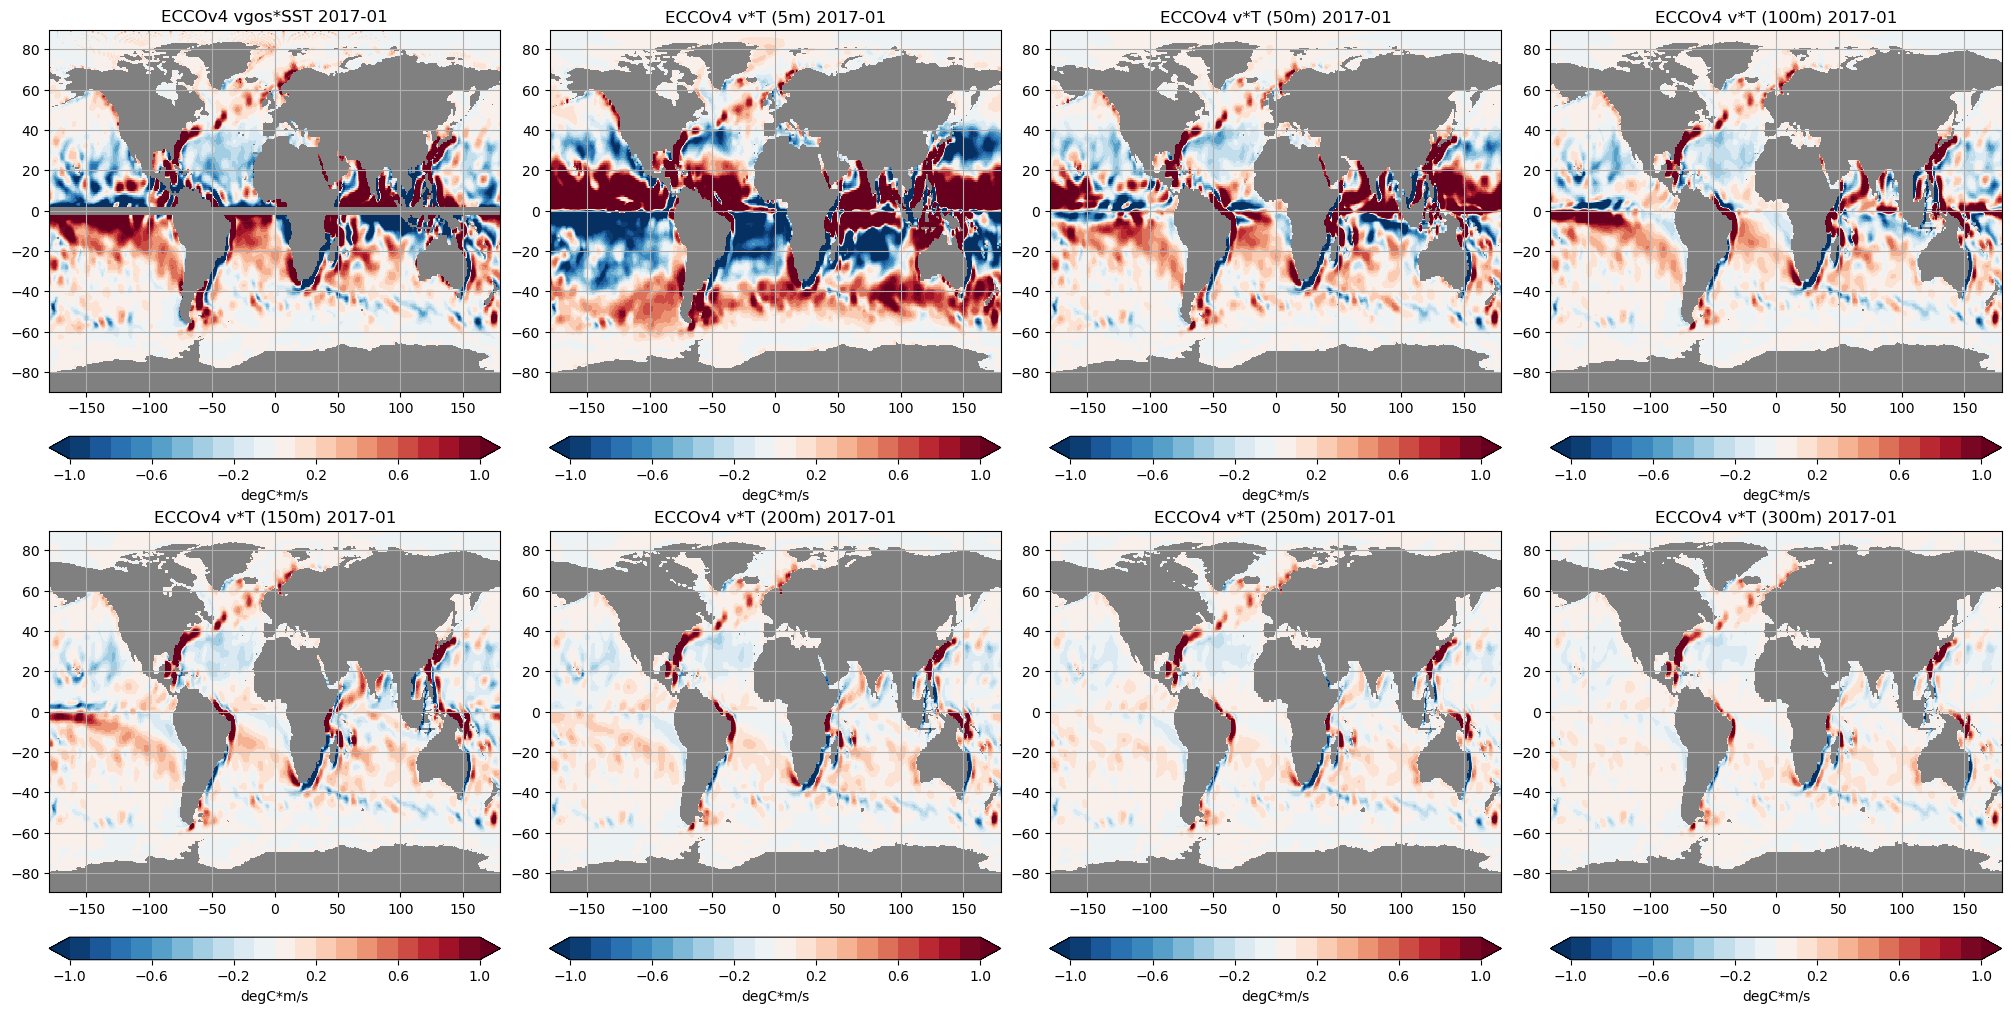

In [19]:
fig,axs = plt.subplots(2,4,figsize=(20,10),layout='constrained')

ax = axs[0,0] ; ax.set_title('ECCOv4 vgos*SST 2017-01')
dat = (sst_ecco4_ds*vgos_ecco4_5deg).mean('time')
cmap = 'RdBu_r' ; levels = np.linspace(-1,1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='degC*m/s')

ax = axs[0,1] ; ax.set_title('ECCOv4 v*T (5m) 2017-01')
dat = vt_ecco4_5deg.mean('time').interp(Z=-5)
cmap = 'RdBu_r' ; levels = np.linspace(-1,1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='degC*m/s')

ax = axs[0,2] ; ax.set_title('ECCOv4 v*T (50m) 2017-01')
dat = vt_ecco4_5deg.mean('time').interp(Z=-50)
cmap = 'RdBu_r' ; levels = np.linspace(-1,1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='degC*m/s')

ax = axs[0,3] ; ax.set_title('ECCOv4 v*T (100m) 2017-01')
dat = vt_ecco4_5deg.mean('time').interp(Z=-100)
cmap = 'RdBu_r' ; levels = np.linspace(-1,1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='degC*m/s')

ax = axs[1,0] ; ax.set_title('ECCOv4 v*T (150m) 2017-01')
dat = vt_ecco4_5deg.mean('time').interp(Z=-150)
cmap = 'RdBu_r' ; levels = np.linspace(-1,1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='degC*m/s')

ax = axs[1,1] ; ax.set_title('ECCOv4 v*T (200m) 2017-01')
dat = vt_ecco4_5deg.mean('time').interp(Z=-200)
cmap = 'RdBu_r' ; levels = np.linspace(-1,1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='degC*m/s')

ax = axs[1,2] ; ax.set_title('ECCOv4 v*T (250m) 2017-01')
dat = vt_ecco4_5deg.mean('time').interp(Z=-250)
cmap = 'RdBu_r' ; levels = np.linspace(-1,1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='degC*m/s')

ax = axs[1,3] ; ax.set_title('ECCOv4 v*T (300m) 2017-01')
dat = vt_ecco4_5deg.mean('time').interp(Z=-300)
cmap = 'RdBu_r' ; levels = np.linspace(-1,1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='degC*m/s')

for ax in axs.flat:
    ax.grid()
    ax.set_facecolor('gray')
    

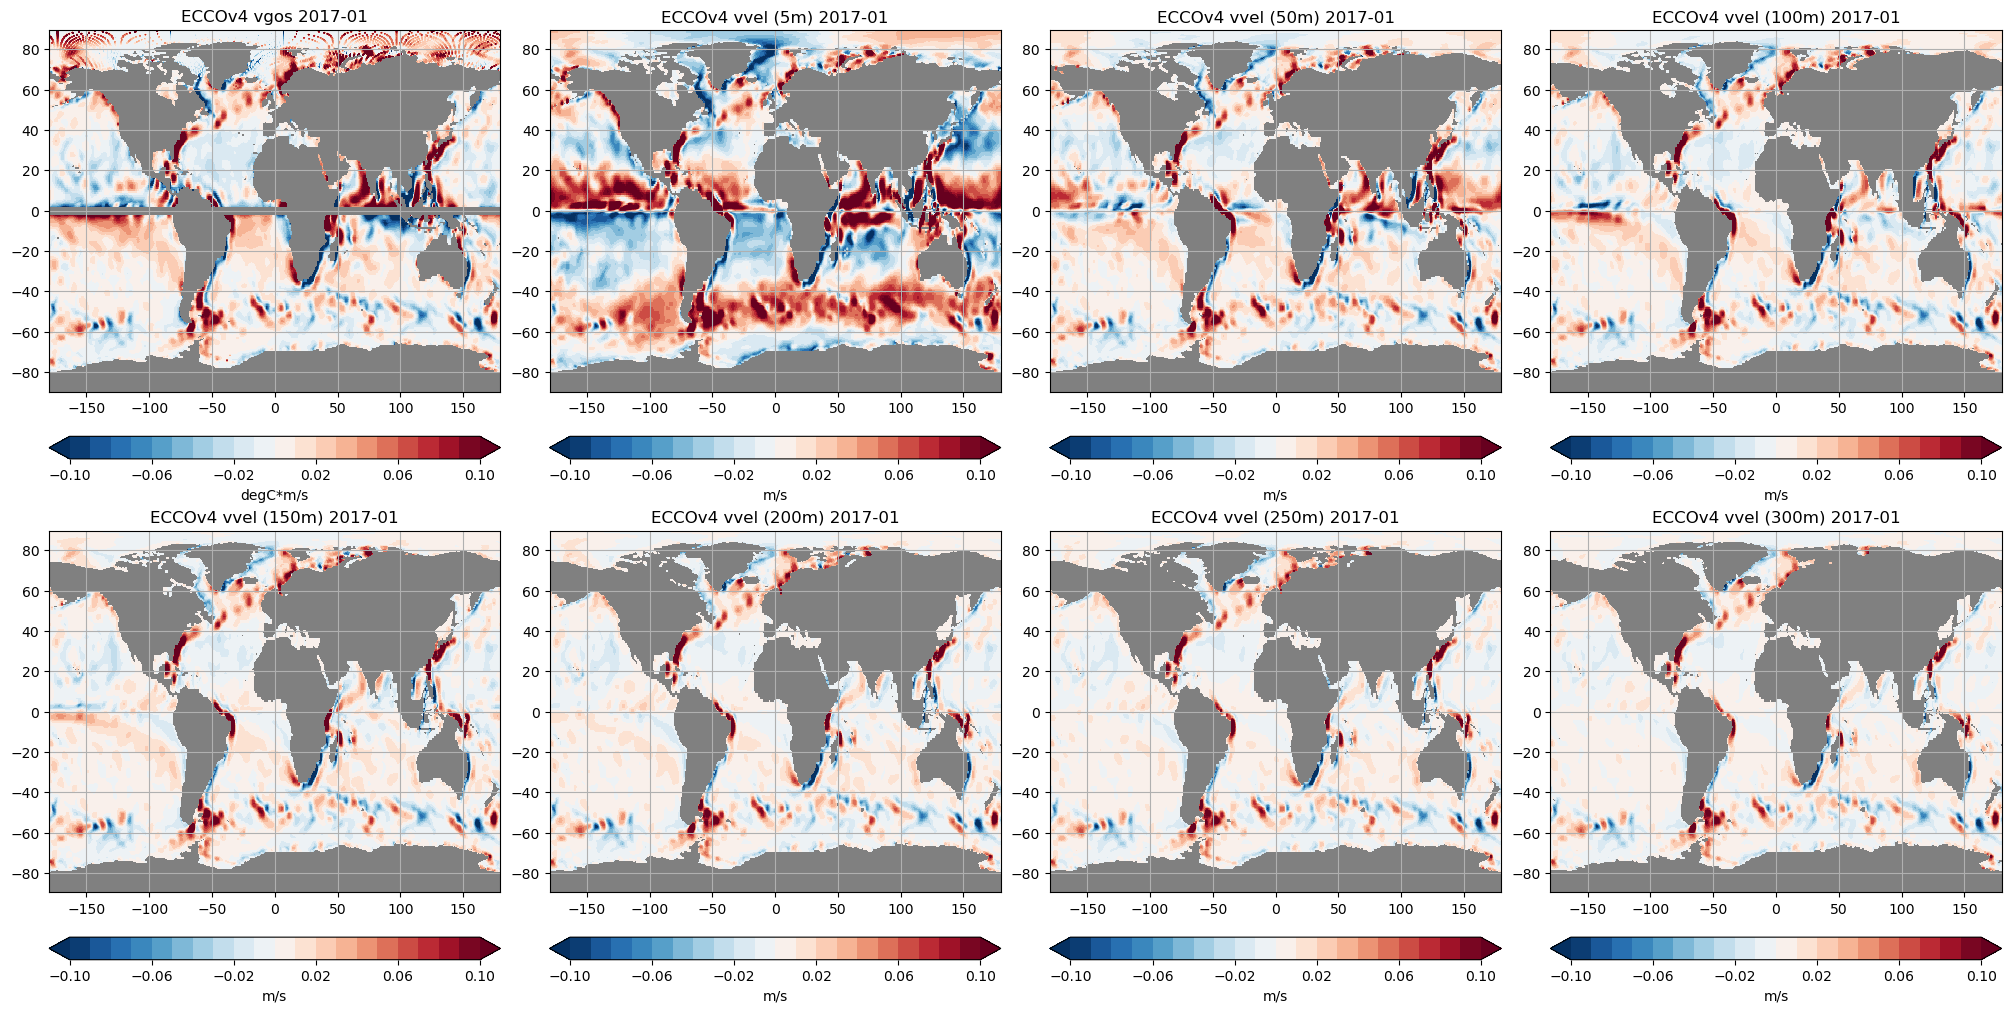

In [58]:
fig,axs = plt.subplots(2,4,figsize=(20,10),layout='constrained')

cmap = 'RdBu_r' ; levels = np.linspace(-0.1,0.1,21)

ax = axs[0,0] ; ax.set_title('ECCOv4 vgos 2017-01')
dat = vgos_ecco4_5deg.mean('time')
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='degC*m/s')

ax = axs[0,1] ; ax.set_title('ECCOv4 vvel (5m) 2017-01')
dat = vvel_ecco4_5deg.mean('time').sel(Z=-5)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='m/s')

ax = axs[0,2] ; ax.set_title('ECCOv4 vvel (50m) 2017-01')
dat = vvel_ecco4_5deg.mean('time').interp(Z=-50)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='m/s')

ax = axs[0,3] ; ax.set_title('ECCOv4 vvel (100m) 2017-01')
dat = vvel_ecco4_5deg.mean('time').interp(Z=-100)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='m/s')

ax = axs[1,0] ; ax.set_title('ECCOv4 vvel (150m) 2017-01')
dat = vvel_ecco4_5deg.mean('time').interp(Z=-150)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='m/s')

ax = axs[1,1] ; ax.set_title('ECCOv4 vvel (200m) 2017-01')
dat = vvel_ecco4_5deg.mean('time').interp(Z=-200)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='m/s')

ax = axs[1,2] ; ax.set_title('ECCOv4 vvel (250m) 2017-01')
dat = vvel_ecco4_5deg.mean('time').interp(Z=-250)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='m/s')

ax = axs[1,3] ; ax.set_title('ECCOv4 vvel (300m) 2017-01')
dat = vvel_ecco4_5deg.mean('time').interp(Z=-300)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='m/s')

for ax in axs.flat:
    ax.grid()
    ax.set_facecolor('gray')
    

In [61]:
vt_ecco4_5deg.Z

<xarray.DataArray 'Z' (Z: 50)> Size: 200B
array([-5.000000e+00, -1.500000e+01, -2.500000e+01, -3.500000e+01,
       -4.500000e+01, -5.500000e+01, -6.500000e+01, -7.500500e+01,
       -8.502500e+01, -9.509500e+01, -1.053100e+02, -1.158700e+02,
       -1.271500e+02, -1.397400e+02, -1.544700e+02, -1.724000e+02,
       -1.947350e+02, -2.227100e+02, -2.574700e+02, -2.999300e+02,
       -3.506800e+02, -4.099300e+02, -4.774700e+02, -5.527100e+02,
       -6.347350e+02, -7.224000e+02, -8.144700e+02, -9.097400e+02,
       -1.007155e+03, -1.105905e+03, -1.205535e+03, -1.306205e+03,
       -1.409150e+03, -1.517095e+03, -1.634175e+03, -1.765135e+03,
       -1.914150e+03, -2.084035e+03, -2.276225e+03, -2.491250e+03,
       -2.729250e+03, -2.990250e+03, -3.274250e+03, -3.581250e+03,
       -3.911250e+03, -4.264250e+03, -4.640250e+03, -5.039250e+03,
       -5.461250e+03, -5.906250e+03], dtype=float32)
Coordinates:
  * Z        (Z) float32 200B -5.0 -15.0 -25.0 ... -5.461e+03 -5.906e+03
Attributes:
    axis:                   Z
    bounds:                 Z_bnds
    comment:                Non-uniform vertical spacing.
    coverage_content_type:  coordinate
    long_name:              depth of grid cell center
    positive:               up
    standard_name:          depth
    units:                  m

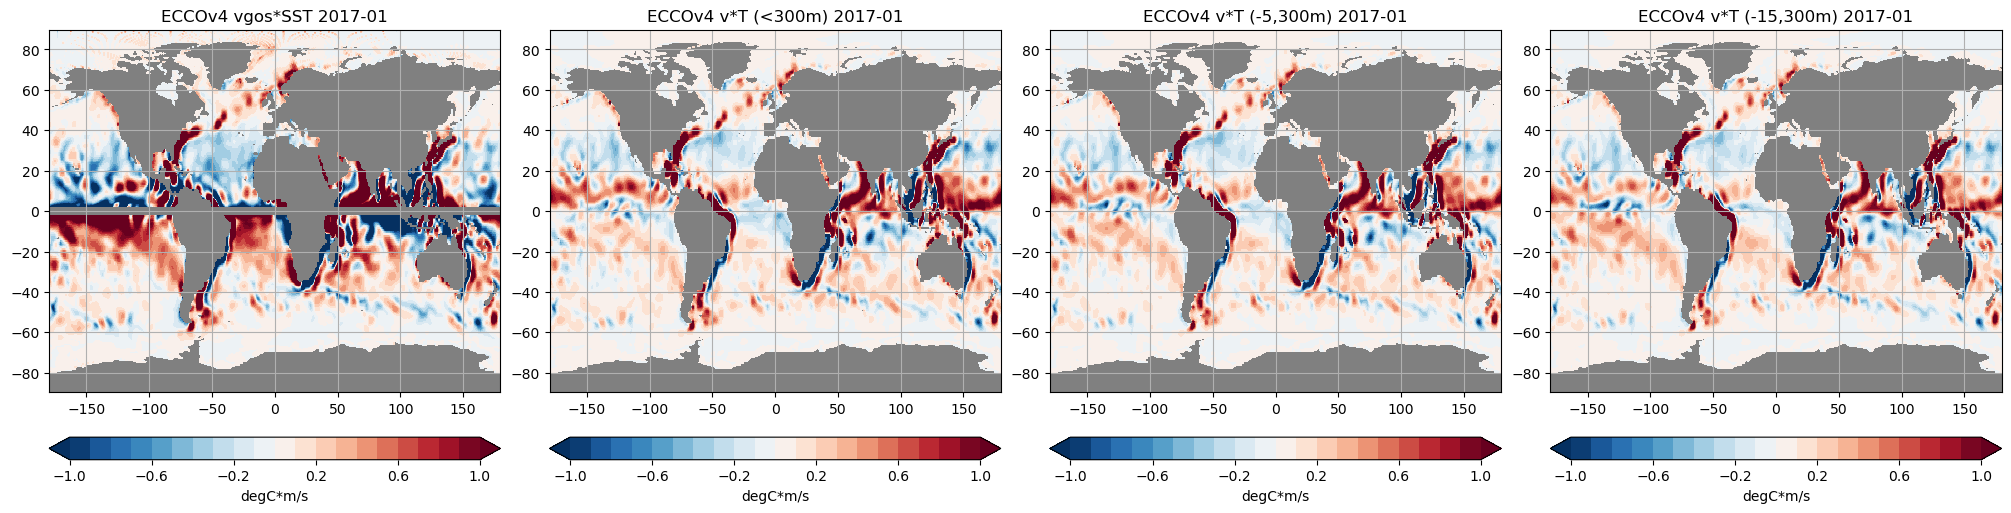

In [62]:
fig,axs = plt.subplots(1,4,figsize=(20,5),layout='constrained')

ax = axs[0] ; ax.set_title('ECCOv4 vgos*SST 2017-01')
dat = (sst_ecco4_ds*vgos_ecco4_5deg).mean('time')
cmap = 'RdBu_r' ; levels = np.linspace(-1,1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='degC*m/s')

ax = axs[1] ; ax.set_title('ECCOv4 v*T (<300m) 2017-01')
dat = vt_ecco4_5deg.mean('time').sel(Z=slice(None,-300)).mean('Z')
cmap = 'RdBu_r' ; levels = np.linspace(-1,1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='degC*m/s')

ax = axs[2] ; ax.set_title('ECCOv4 v*T (-5,300m) 2017-01')
dat = vt_ecco4_5deg.mean('time').sel(Z=slice(-6,-300)).mean('Z')
cmap = 'RdBu_r' ; levels = np.linspace(-1,1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='degC*m/s')

ax = axs[3] ; ax.set_title('ECCOv4 v*T (-15,300m) 2017-01')
dat = vt_ecco4_5deg.mean('time').sel(Z=slice(-16,-300)).mean('Z')
cmap = 'RdBu_r' ; levels = np.linspace(-1,1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='degC*m/s')

for ax in axs:
    ax.grid()
    ax.set_facecolor('gray')
    

# Surface heat transport estimate

In [17]:
short_name = "ECCO_L4_MIXED_LAYER_DEPTH_05DEG_DAILY_V4R4"
mld_ecco4_results = earthaccess.search_data(
    short_name=short_name,
    cloud_hosted=True,
    temporal=("2017-01-01", "2017-01-31"),
)

opened = earthaccess.open(mld_ecco4_results)

mld_ecco4_ds = xr.open_mfdataset(opened,chunks=chunks,data_vars='minimal',
                                 combine='by_coords',coords='minimal',
                                  preprocess=preprocessor,parallel=True)
mld_ecco4_ds

QUEUEING TASKS | :   0%|          | 0/32 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/32 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/32 [00:00<?, ?it/s]

/tmp/ipykernel_109/963232503.py:10: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  mld_ecco4_ds = xr.open_mfdataset(opened,chunks=chunks,data_vars='minimal',
/tmp/ipykernel_109/963232503.py:10: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  mld_ecco4_ds = xr.open_mfdataset(opened,chunks=chunks,data_vars='minimal',


<xarray.Dataset> Size: 33MB
Dimensions:         (time: 32, lat: 360, lon: 720, nv: 2)
Coordinates:
  * time            (time) datetime64[ns] 256B 2016-12-31T12:00:00 ... 2017-0...
  * lat             (lat) float32 1kB -89.75 -89.25 -88.75 ... 88.75 89.25 89.75
  * lon             (lon) float32 3kB -179.8 -179.2 -178.8 ... 178.8 179.2 179.8
    time_bnds       (time, nv) datetime64[ns] 512B dask.array<chunksize=(1, 2), meta=np.ndarray>
    latitude_bnds   (lat, nv) float32 3kB dask.array<chunksize=(360, 2), meta=np.ndarray>
    longitude_bnds  (lon, nv) float32 6kB dask.array<chunksize=(720, 2), meta=np.ndarray>
Dimensions without coordinates: nv
Data variables:
    MXLDEPTH        (time, lat, lon) float32 33MB dask.array<chunksize=(1, 360, 720), meta=np.ndarray>
Attributes: (12/57)
    acknowledgement:              This research was carried out by the Jet Pr...
    author:                       Ian Fenty and Ou Wang
    cdm_data_type:                Grid
    comment:                      Fields provided on a regular lat-lon grid. ...
    Conventions:                  CF-1.8, ACDD-1.3
    coordinates_comment:          Note: the global 'coordinates' attribute de...
    ...                           ...
    time_coverage_duration:       P1D
    time_coverage_end:            2017-01-01T00:00:00
    time_coverage_resolution:     P1D
    time_coverage_start:          2016-12-31T00:00:00
    title:                        ECCO Ocean Mixed Layer Depth - Daily Mean 0...
    uuid:                         61ce2742-4052-11eb-a51b-0cc47a3f7e1d

In [21]:
mld_ecco4_5deg = mld_ecco4_ds.MXLDEPTH

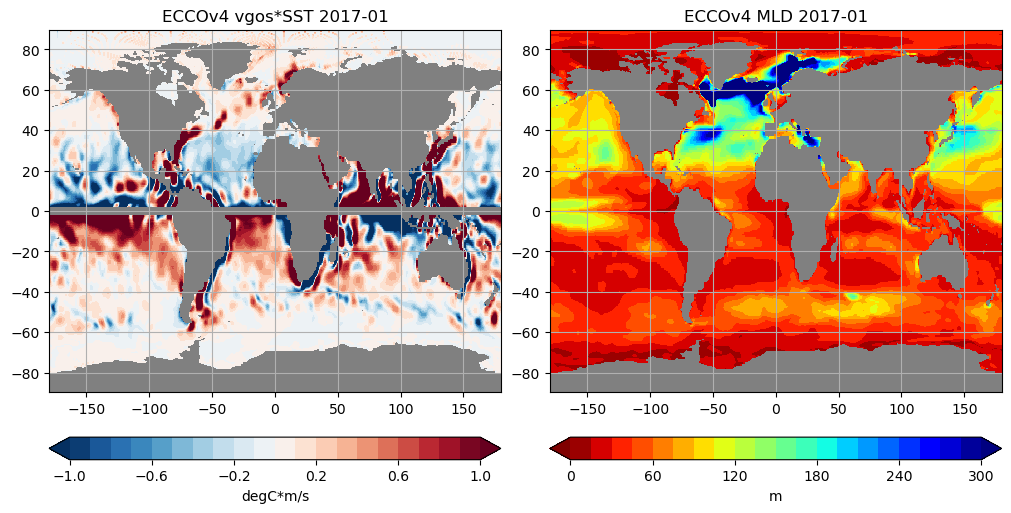

In [23]:
fig,axs = plt.subplots(1,2,figsize=(10,5),layout='constrained')

ax = axs[0] ; ax.set_title('ECCOv4 vgos*SST 2017-01')
dat = (sst_ecco4_ds*vgos_ecco4_5deg).mean('time')
cmap = 'RdBu_r' ; levels = np.linspace(-1,1,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='degC*m/s')

ax = axs[1] ; ax.set_title('ECCOv4 MLD 2017-01')
dat = mld_ecco4_5deg.mean('time')
cmap = 'jet_r' ; levels = np.linspace(0,300,21)
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='m')

for ax in axs:
    ax.grid()
    ax.set_facecolor('gray')
    

In [45]:
vt_ecco4_5deg_jan = vt_ecco4_5deg.mean('time')

mask = vt_ecco4_5deg.Z > -mld_ecco4_5deg.mean('time')
vt_ecco4_5deg_ml = vt_ecco4_5deg.where(mask)

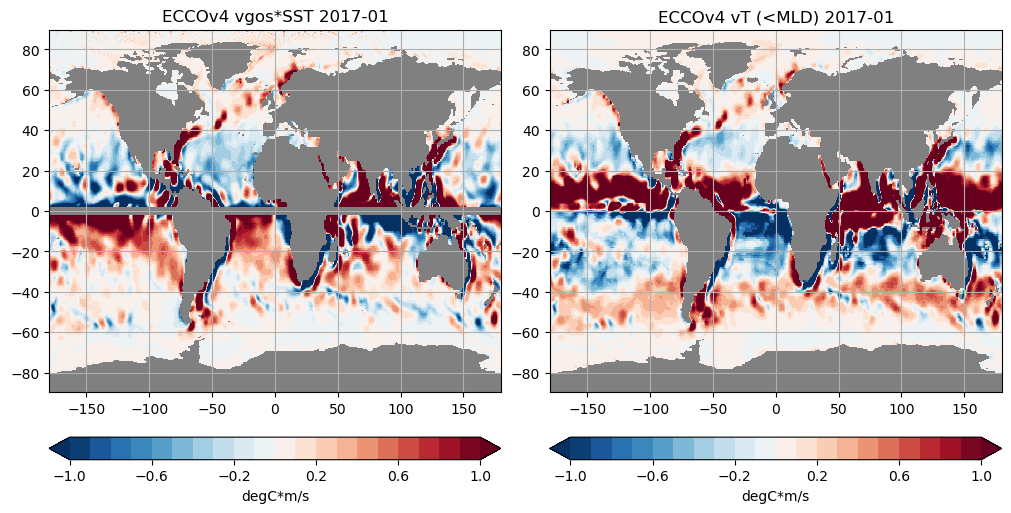

In [68]:
fig,axs = plt.subplots(1,2,figsize=(10,5),layout='constrained')

cmap = 'RdBu_r' ; levels = np.linspace(-1,1,21)

ax = axs[0] ; ax.set_title('ECCOv4 vgos*SST 2017-01')
dat = (sst_ecco4_ds*vgos_ecco4_5deg).mean('time')
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='degC*m/s')

ax = axs[1] ; ax.set_title('ECCOv4 vT (<MLD) 2017-01')
dat = vt_ecco4_5deg_ml.mean('time').mean('Z')
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='degC*m/s')

for ax in axs:
    ax.grid()
    ax.set_facecolor('gray')
    

/srv/conda/envs/notebook/lib/python3.12/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/srv/conda/envs/notebook/lib/python3.12/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


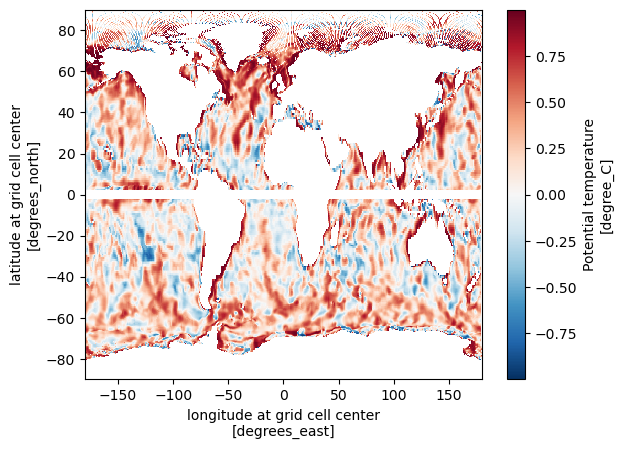

In [219]:
xr.corr((sst_ecco4_ds*vgos_ecco4_5deg),vt_ecco4_5deg_ml.mean('Z'),dim='time').plot()

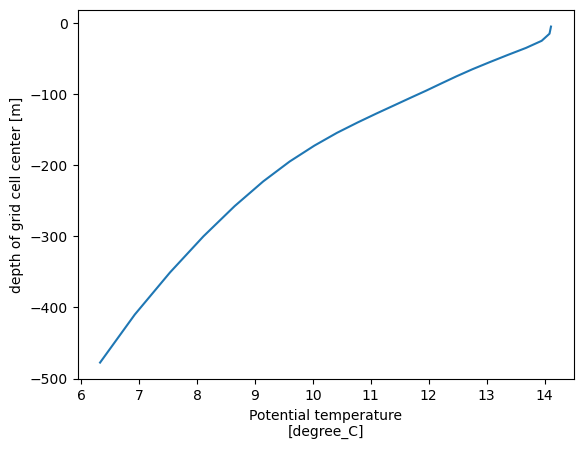

In [72]:
temp_ecco4_5deg.mean(('time','lat','lon')).sel(Z=slice(0,-500)).plot(y='Z')

In [ ]:
temp_ecco4_5deg.mean(('time','lat','lon')).sel(Z=slice(0,-500)).plot(y='Z')

In [170]:
import xarray as xr
import numpy as np

def generate_linear_temp_3d(sst, mld, z_levels, t_min=4.0):
    """
    Creates a 3D temperature field where TEMP decreases linearly 
    from SST at the surface to t_min at a specified MLD value.
    
    Parameters:
    -----------
    sst : xr.DataArray (dims: y, x)
        2D surface temperature.
    mld : xr.DataArray (dims: y, x)
        2D mixed layer depth (positive values).
    z_levels : array-like
        1D array of depths for the output (e.g., np.arange(0, 500, 10)).
    t_min : float
        The temperature at (and below) the MLD.
    """
    z = xr.DataArray(z_levels, coords={'Z': z_levels}, dims='Z')

    fraction = z / mld
    fraction = fraction.where(fraction <= 1, 1)

    total_drop = sst - t_min
    temp_3d = sst - (total_drop * fraction)

    return temp_3d

In [189]:
sst = temp_ecco4_5deg.isel(Z=0,time=0)
mld = mld_ecco4_5deg.isel(time=0)
test = generate_linear_temp_3d(sst,-500,temp_ecco4_5deg.Z.sel(Z=slice(0,-1000)),sst-8)

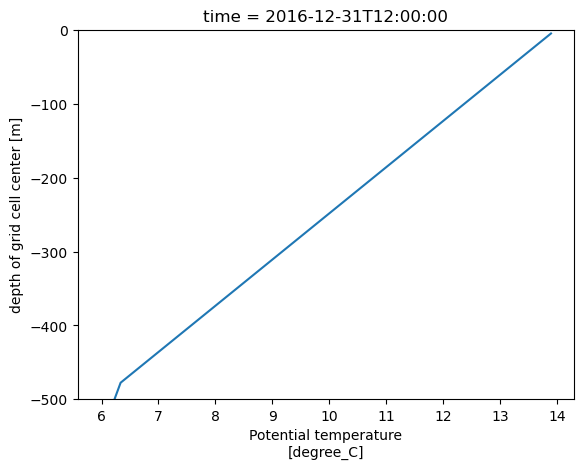

In [197]:
test.mean(('lat','lon')).plot(y='Z',ylim=(-500,0))

In [192]:
temp_ML_ecco4_5deg = generate_linear_temp_3d(sst_ecco4_ds,-500,
                                             temp_ecco4_5deg.Z.sel(Z=slice(0,-1000)),sst_ecco4_ds-8)

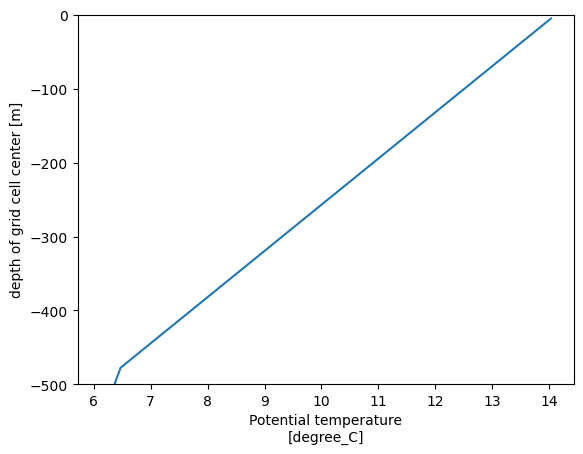

In [195]:
temp_ML_ecco4_5deg.mean(('time','lat','lon')).plot(y='Z',ylim=(-500,0))

In [199]:
vt_geo_ecco4_5deg = (temp_ML_ecco4_5deg*vgos_ecco4_5deg).where(mask).mean('Z')

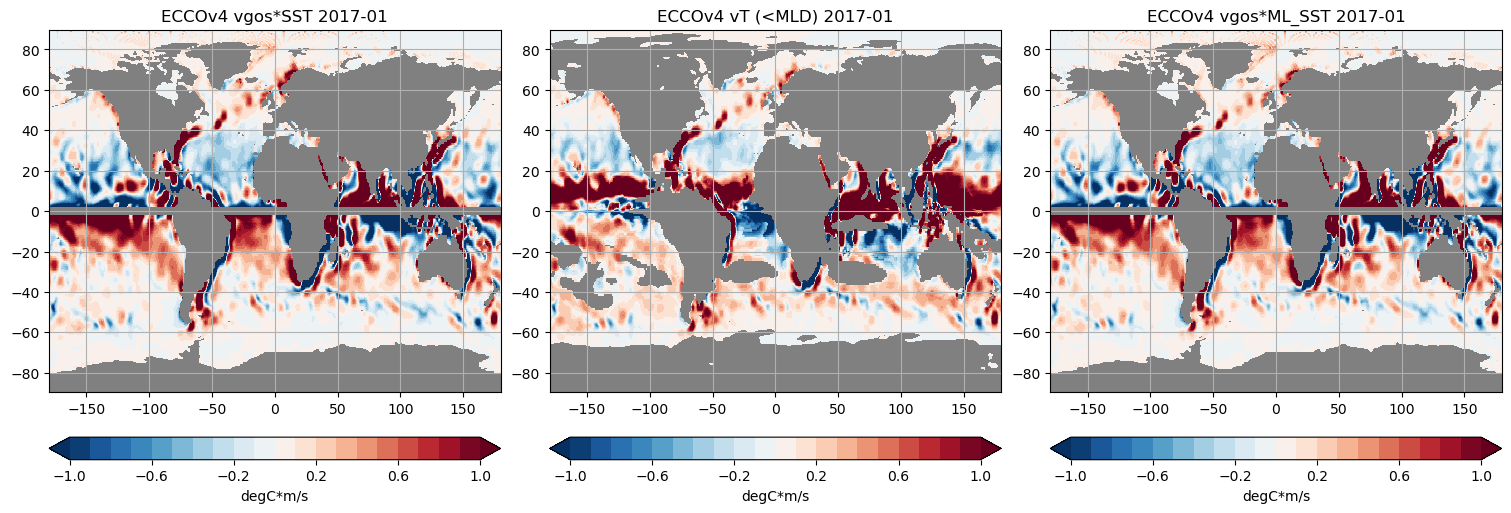

In [202]:
fig,axs = plt.subplots(1,3,figsize=(15,5),layout='constrained')

cmap = 'RdBu_r' ; levels = np.linspace(-1,1,21)

ax = axs[0] ; ax.set_title('ECCOv4 vgos*SST 2017-01')
dat = (sst_ecco4_ds*vgos_ecco4_5deg).mean('time')
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='degC*m/s')

ax = axs[1] ; ax.set_title('ECCOv4 vT (<MLD) 2017-01')
dat = vt_ecco4_5deg_ml.mean('time').sel(Z=slice(-20,None)).mean('Z')
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='degC*m/s')

ax = axs[2] ; ax.set_title('ECCOv4 vgos*ML_SST 2017-01')
dat = vt_geo_ecco4_5deg.mean('time')
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='degC*m/s')

for ax in axs:
    ax.grid()
    ax.set_facecolor('gray')
    

In [220]:
test2 = (temp_ecco4_5deg*(vvel_ecco4_5deg.sel(Z=slice(-10,None)).mean('Z'))).where(mask).mean('Z')
test3 = ((temp_ecco4_5deg.isel(Z=0)-4)*vgos_ecco4_5deg)

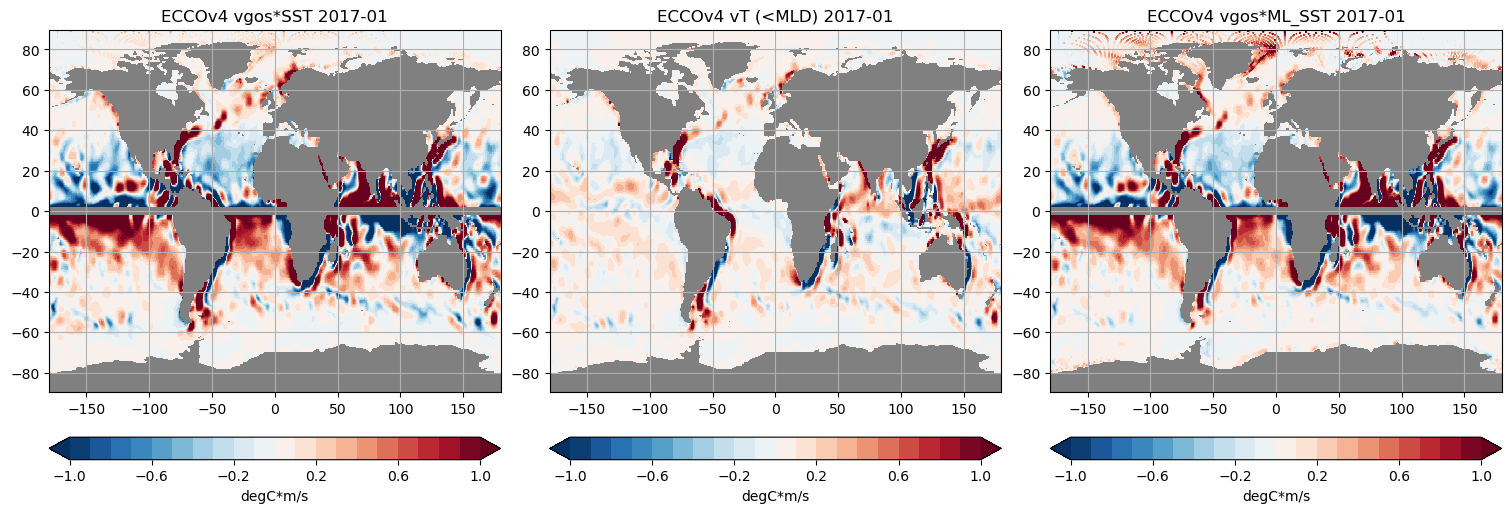

In [221]:
fig,axs = plt.subplots(1,3,figsize=(15,5),layout='constrained')

cmap = 'RdBu_r' ; levels = np.linspace(-1,1,21)

ax = axs[0] ; ax.set_title('ECCOv4 vgos*SST 2017-01')
dat = (sst_ecco4_ds*vgos_ecco4_5deg).mean('time')
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='degC*m/s')

ax = axs[1] ; ax.set_title('ECCOv4 vT (<MLD) 2017-01')
dat = test2.mean('time')
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='degC*m/s')

ax = axs[2] ; ax.set_title('ECCOv4 vgos*ML_SST 2017-01')
dat = test3.mean('time')
f = ax.contourf(dat.lon,dat.lat,dat,cmap=cmap,levels=levels,extend='both')
plt.colorbar(f,ax=ax,ticks=levels[::4],orientation='horizontal',label='degC*m/s')

for ax in axs:
    ax.grid()
    ax.set_facecolor('gray')
    

/srv/conda/envs/notebook/lib/python3.12/site-packages/dask/array/numpy_compat.py:61: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/srv/conda/envs/notebook/lib/python3.12/site-packages/dask/_task_spec.py:759: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)


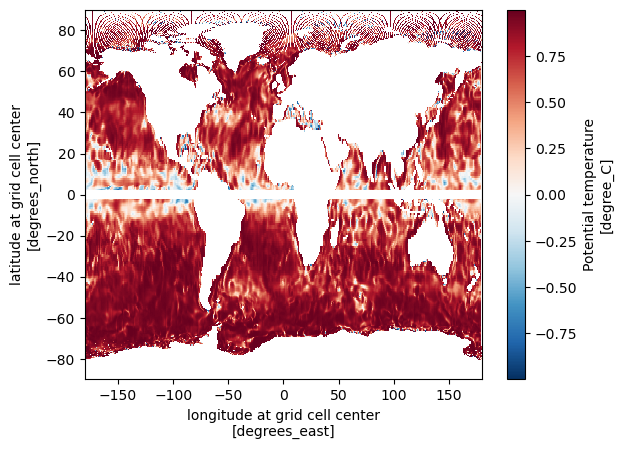

In [224]:
xr.corr(sst_ecco4_ds*vgos_ecco4_5deg,test2,dim='time').plot()

# Surface heat transport estimate in observation